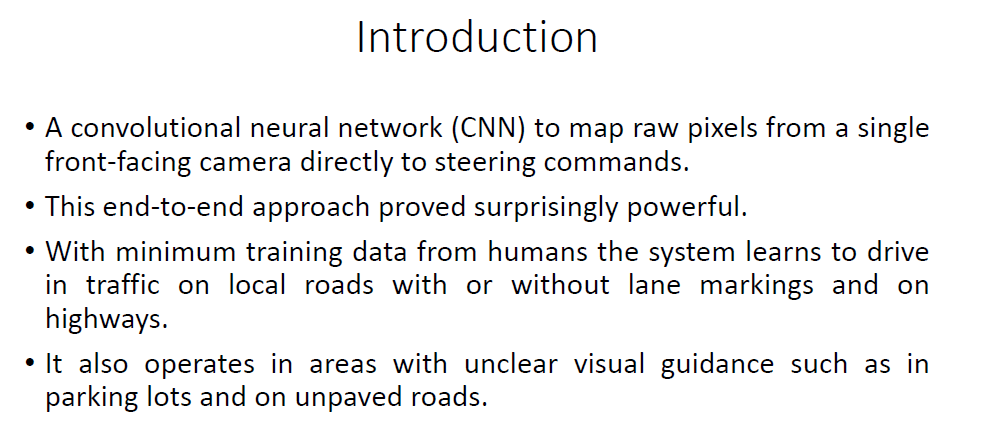

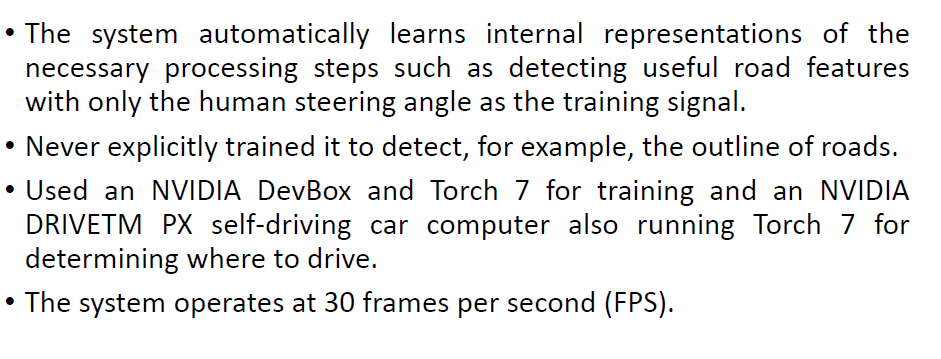

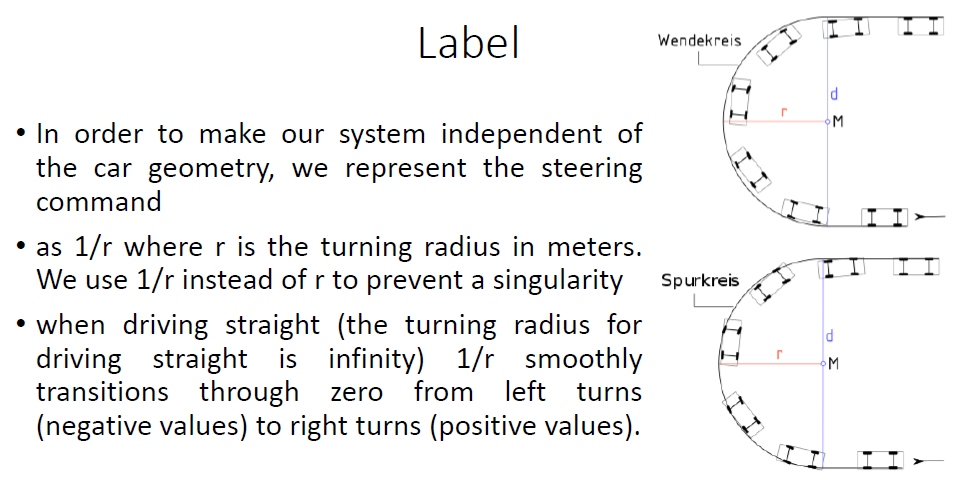

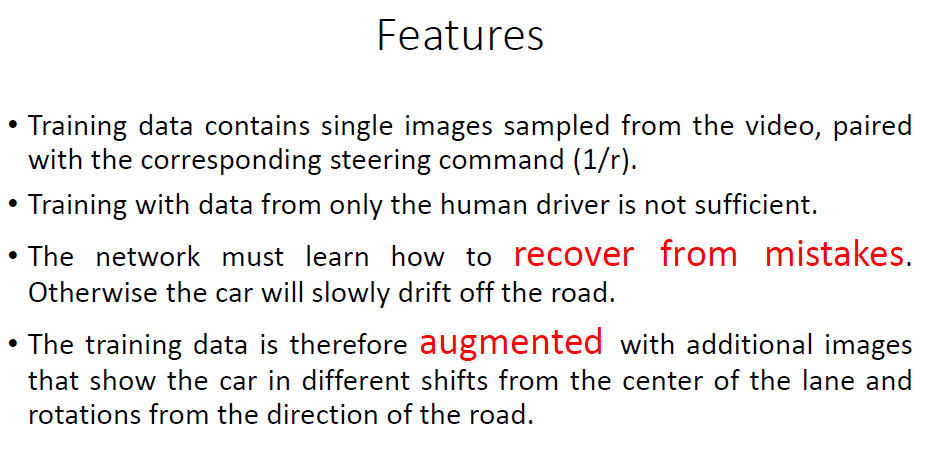

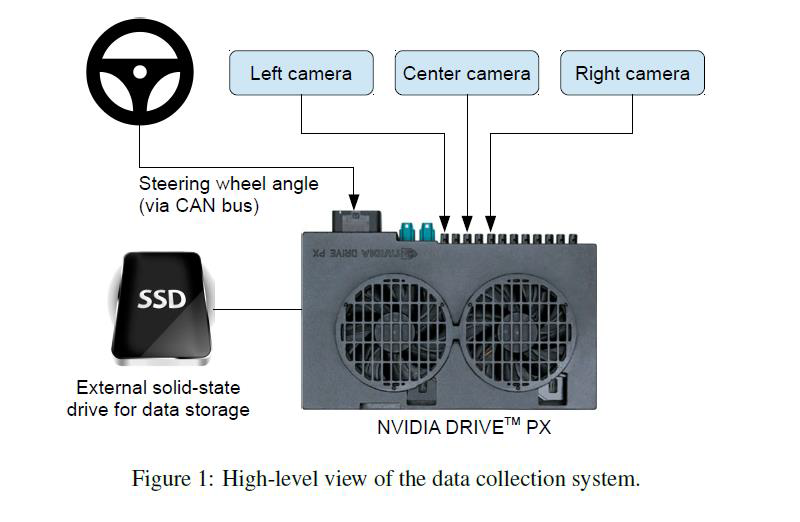

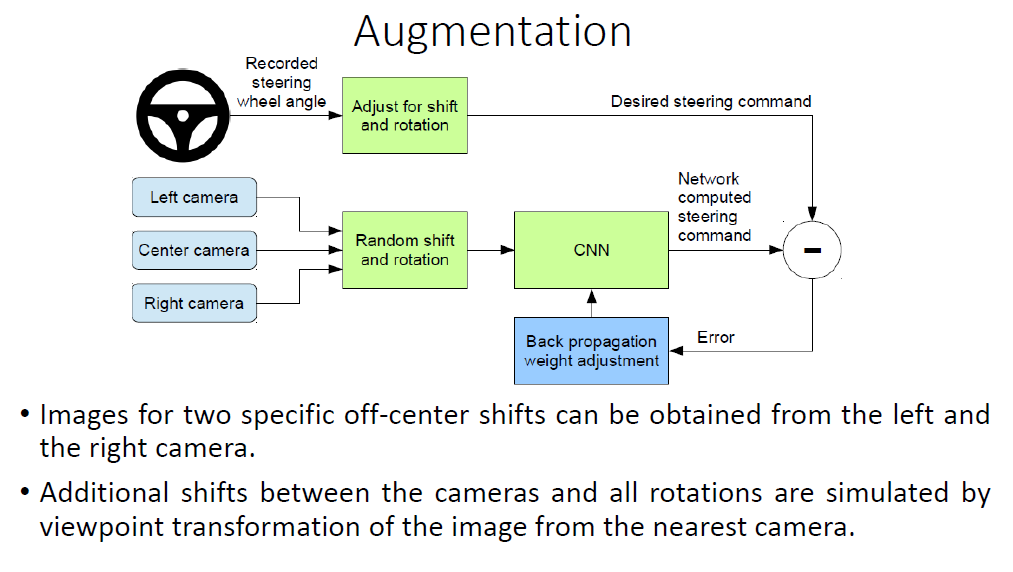

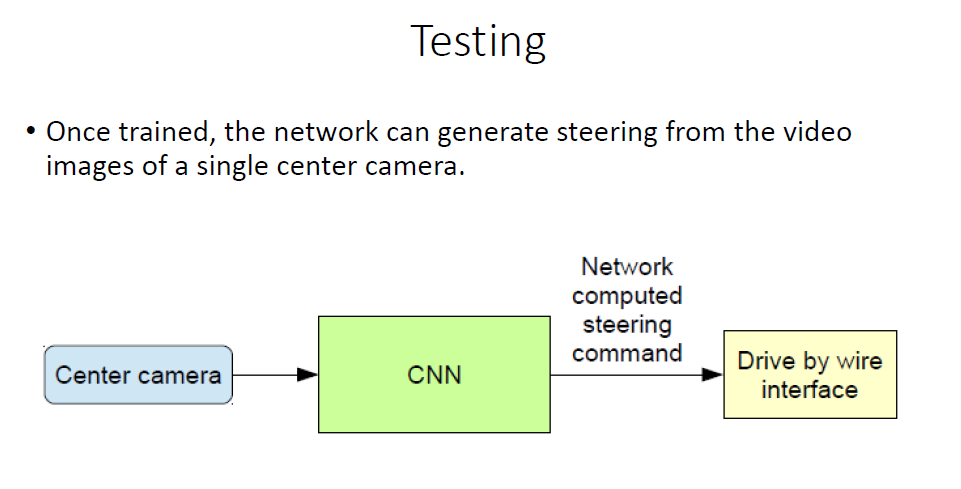

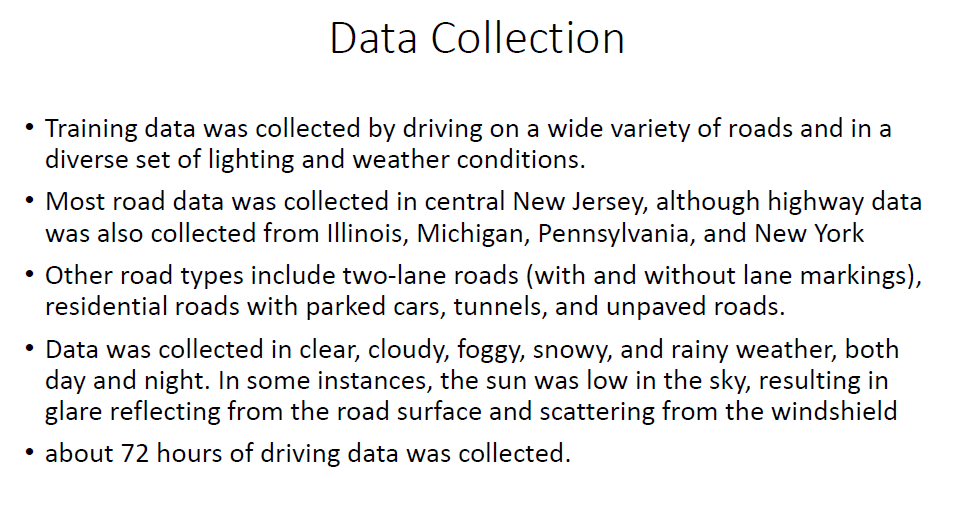

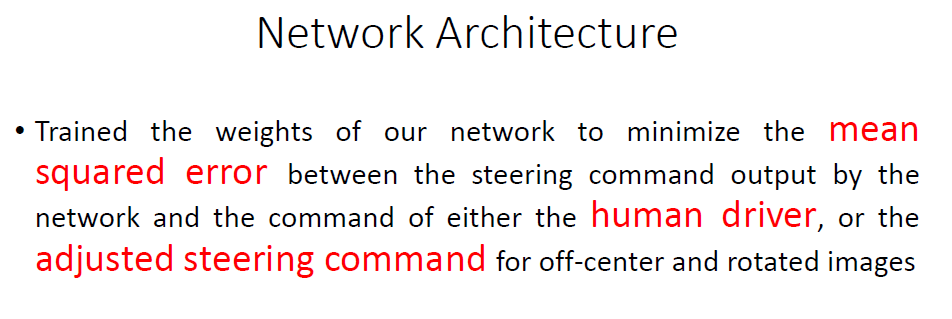

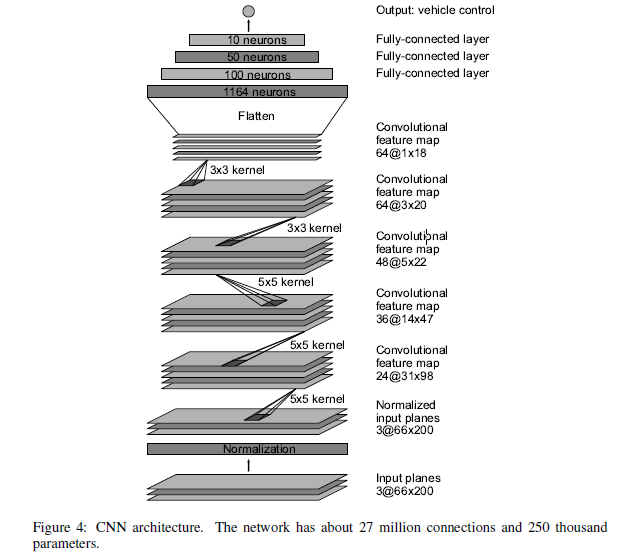

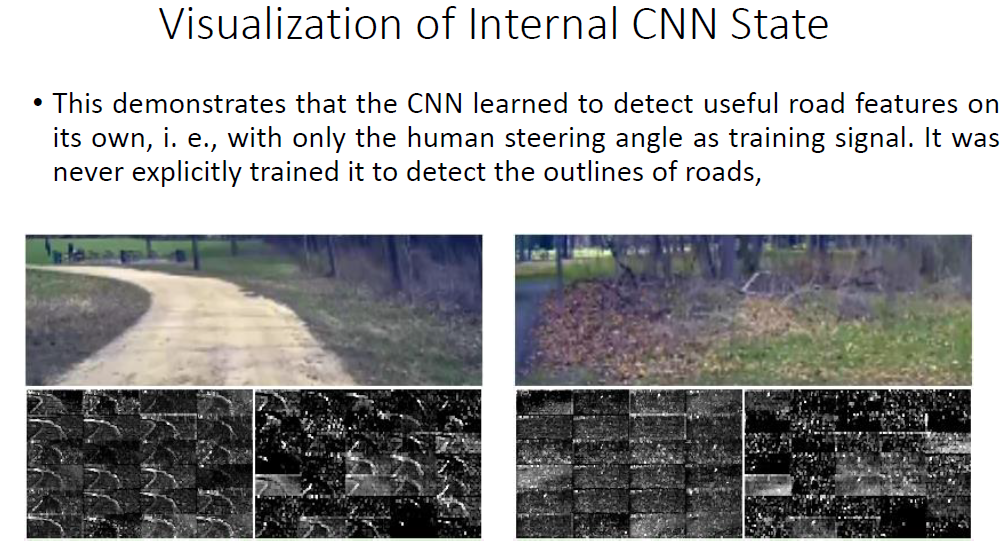

# References

Bojarski, Mariusz& Testa, Davide& Dworakowski, Daniel & Firner, Bernhard & Flepp, Beat & Goyal, Prasoon& Jackel, Larry & Monfort, Mathew & Muller, Urs& Zhang, Jiakai& Zhang, Xin & Zhao, Jake & Zieba, Karol. (2016). End to End Learning for Self-Driving Cars.

# Installing the Environment

1. ```conda create -n self-driving-car```
2. ```conda activate self-driving-car```
3. ```pip install -r requirements.txt```

In [59]:
import os

import csv
import cv2
import matplotlib.pyplot as plt
import random
import matplotlib.image as mpimg

In [60]:
data_path='data'
label_path='data/driving_log.csv'

In [61]:
import pandas as pd
import numpy as np

dataset=pd.read_csv(label_path)
dataset.head()

,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IMG\center_2022_09_18_12_03_15_935.jpg,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IMG\left_2022_09_18_12_03_15_935.jpg,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IMG\right_2022_09_18_12_03_15_935.jpg,0,0.1,0.2,7.98E-05
0,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,-0.060888,1.0,0.0,3.214743
1,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,-0.052751,1.0,0.0,5.779959
2,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,-0.197497,1.0,0.0,6.913286
3,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,-0.095900,1.0,0.0,9.172904
4,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,C:\Users\DELL\Desktop\SELF DRIVING CAR\data\IM...,-0.401264,1.0,0.0,10.243550


In [62]:
dataset=dataset.values
data=dataset[:,0:3]
target=dataset[:,3]

In [63]:
from sklearn.model_selection import train_test_split

train_data,test_data,train_target,test_target=train_test_split(data,target,test_size=0.1)

In [64]:
def load_image(data_dir, image_file):

    return mpimg.imread(os.path.join(data_dir, image_file.strip()))

In [65]:
test_data[100][2]

'C:\\Users\\DELL\\Desktop\\SELF DRIVING CAR\\data\\IMG\\right_2022_09_20_23_53_14_713.jpg'

-0.6000001


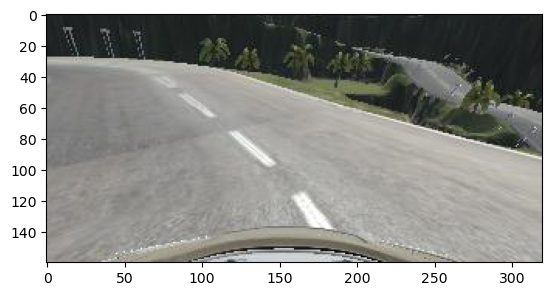

In [66]:
img=load_image(data_path,test_data[0][0])
plt.imshow(img)
steering_angle=test_target[0]
print(steering_angle)

-0.6000001


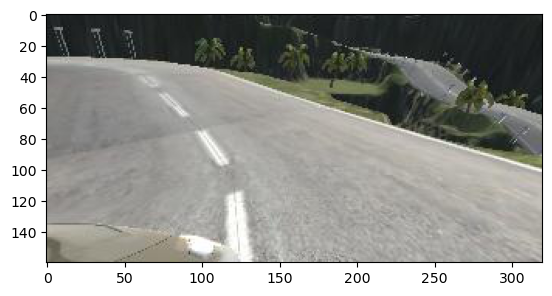

In [67]:
img=load_image(data_path,test_data[0][2])
plt.imshow(img)
steering_angle=test_target[0]
print(steering_angle)

# Data Preprocessing

1. Cropping the image to cut off the sky scene and the car front.
2. Resizing the image to (66 * 200), the image size that the model expects.
3. Converting the image to the YUV color space.
4. Normalizing the images (by dividing image data by 127.5 and subtracting 1.0). As stated in the Model Architecture section, this is to avoid saturation and make gradients work better).

In [68]:
IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS = 66, 200, 3
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS)

In [69]:
def preprocess(img):

    # Cropping the image
    img = img[60:-25, :, :]
    # Resizing the image
    img = cv2.resize(img, (IMAGE_WIDTH, IMAGE_HEIGHT), cv2.INTER_AREA)
    # Converting the image to YUV
    img = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    return img

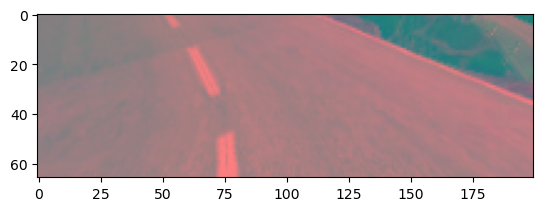

In [70]:
preprocessed_img=preprocess(img)
plt.imshow(preprocessed_img)

In [71]:
def random_adjust(data_dir, center, left, right, steering_angle):

    choice = np.random.choice(3)
    if choice == 0:
        return load_image(data_dir, left), steering_angle + 0.2
    elif choice == 1:
        return load_image(data_dir, right), steering_angle - 0.2
    return load_image(data_dir, center), steering_angle

-0.4000001


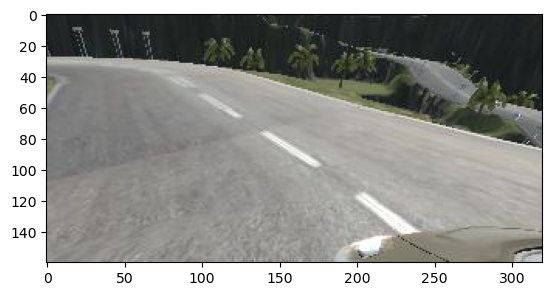

In [72]:
adjusted_img,adjusted_str=random_adjust(data_path,test_data[0][2],test_data[0][1],test_data[0][0],test_target[0])
plt.imshow(adjusted_img)
print(adjusted_str)

In [73]:
def display(image, angle, label):
    plt.imshow(image)
    plt.xlabel("Steering angle: {:.5f}".format(angle))
    plt.title(label)
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [74]:
def random_flip(image, steering_angle):

    if np.random.rand() < 0.5:
        image = cv2.flip(image, 1)
        steering_angle = -steering_angle
    return image, steering_angle

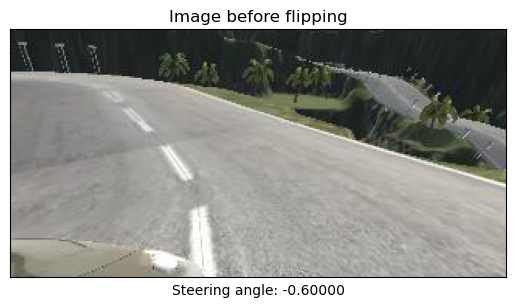

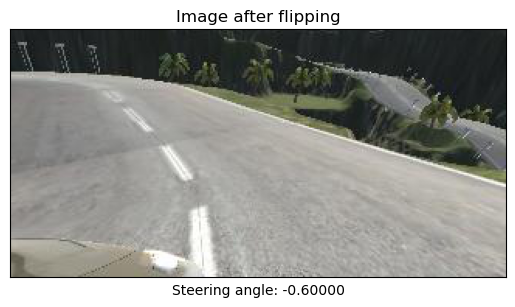

In [75]:
label = "Image before flipping"
display(img, steering_angle, label)

flipped_img,fliiped_str = random_flip(img, steering_angle)
label = "Image after flipping"
display(flipped_img, fliiped_str, label)

In [76]:
def random_shift(image, steering_angle, range_x, range_y):

    trans_x = range_x * (np.random.rand() - 0.5)
    trans_y = range_y * (np.random.rand() - 0.5)
    steering_angle += trans_x * 0.002
    trans_m = np.float32([[1, 0, trans_x], [0, 1, trans_y]])
    height, width = image.shape[:2]
    image = cv2.warpAffine(image, trans_m, (width, height))
    return image, steering_angle

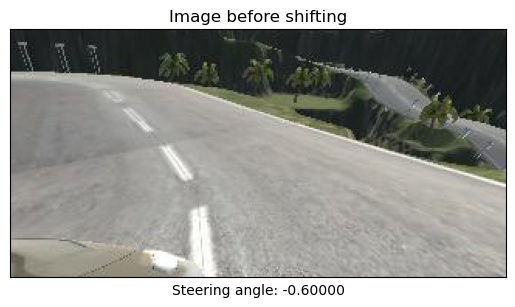

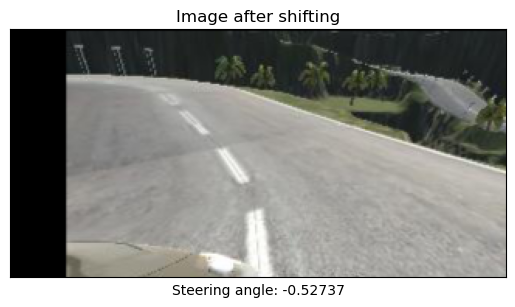

In [77]:
label = "Image before shifting"
display(img, steering_angle, label)

shifted_img,shifted_str = random_shift(img, steering_angle,100, 10)
label = "Image after shifting"
display(shifted_img, shifted_str, label)

In [78]:
def random_shadow(image):

    bright_factor = 0.3
    x = random.randint(0, image.shape[1])
    y = random.randint(0, image.shape[0])
    width = random.randint(image.shape[1], image.shape[1])
    if(x + width > image.shape[1]):
        x = image.shape[1] - x
    height = random.randint(image.shape[0], image.shape[0])
    if(y + height > image.shape[0]):
        y = image.shape[0] - y
    image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    image[y:y+height,x:x+width,2] = image[y:y+height,x:x+width,2]*bright_factor
    return cv2.cvtColor(image, cv2.COLOR_HSV2RGB)

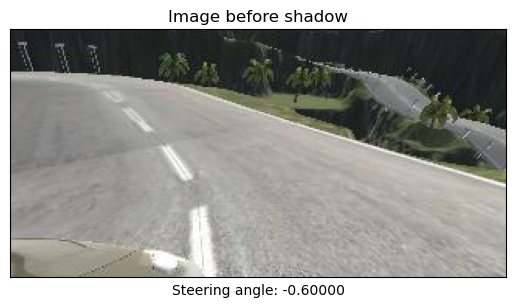

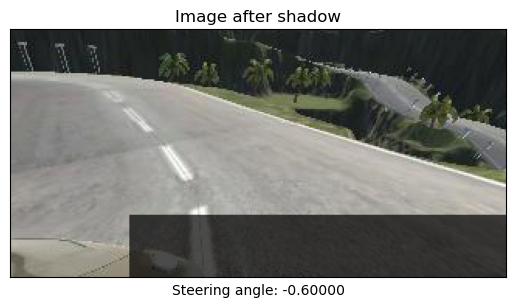

In [79]:
label = "Image before shadow"
display(img, steering_angle, label)

shadow_img = random_shadow(img)
label = "Image after shadow"
display(shadow_img, steering_angle, label)

In [80]:
def random_brightness(image):

    # HSV (Hue, Saturation, Value) is also called HSB ('B' for Brightness).
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    ratio = 1.0 + (np.random.rand() - 0.5)
    hsv[:,:,2] =  hsv[:,:,2] * ratio
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

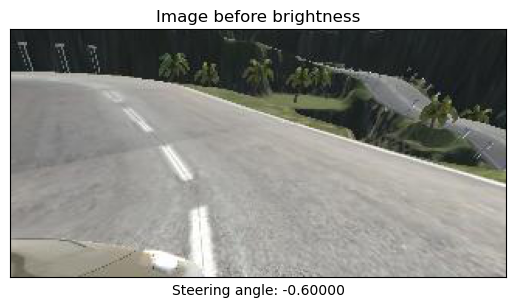

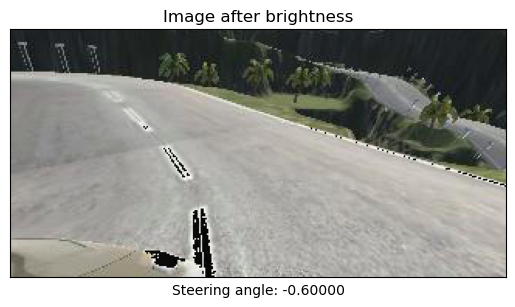

In [81]:
label = "Image before brightness"
display(img, steering_angle, label)

brightness_img = random_brightness(img)
label = "Image after brightness"
display(brightness_img, steering_angle, label)

# Augmentation Function

In [82]:
def augument(data_dir, center, left, right, steering_angle, range_x=100, range_y=10):

    image, steering_angle = random_adjust(data_dir, center, left, right, steering_angle)
    image, steering_angle = random_flip(image, steering_angle)
    image, steering_angle = random_shift(image, steering_angle, range_x, range_y)
    image = random_shadow(image)
    image = random_brightness(image)
    return image, steering_angle

# Nvidia CNN

In [83]:
from keras.models import Sequential
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint
from keras.layers import Lambda, Conv2D, MaxPooling2D, Dropout, Dense, Flatten

def NVIDIA_model():
    
    model = Sequential()
    model.add(Lambda(lambda x: x/127.5-1.0, input_shape=INPUT_SHAPE))
    model.add(Conv2D(24, (5, 5), activation='elu', strides=(2, 2)))
    model.add(Conv2D(36, (5, 5), activation='elu', strides=(2, 2)))
    model.add(Conv2D(48, (5, 5), activation='elu', strides=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='elu'))
    model.add(Conv2D(64, (3, 3), activation='elu'))
    model.add(Dropout(0.5))
    model.add(Flatten())
    model.add(Dense(100, activation='elu'))
    model.add(Dense(50, activation='elu'))
    model.add(Dense(10, activation='elu'))
    model.add(Dense(1))
    model.summary()
    
    model.compile(loss='mse', optimizer=Adam(learning_rate=1.0e-4))
    
    return model

In [84]:
batch_size = 40
samples_per_epoch = 20000
nb_epoch = 10

In [85]:
def batcher(data_dir, image_paths, steering_angles, batch_size, training_flag):

    images = np.empty([batch_size, IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS])
    steers = np.empty(batch_size)
    while True:
        i = 0
        for index in np.random.permutation(image_paths.shape[0]):
            center, left, right = image_paths[index]
            steering_angle = steering_angles[index]
            if training_flag and np.random.rand() < 0.6:
                image, steering_angle = augument(data_dir, center, left, right, steering_angle)
            else:
                image = load_image(data_dir, center) 
            images[i] = preprocess(image)
            steers[i] = steering_angle
            i += 1
            if i == batch_size:
                break
        yield images, steers

In [86]:
def train_model(model, X_train, X_valid, y_train, y_valid):
    
    checkpoint = ModelCheckpoint('model-{val_loss:03f}.h5',monitor='val_loss',save_best_only=True,mode='auto')
    
    model.fit(
    batcher(data_path, X_train, y_train, batch_size, True),
    steps_per_epoch=len(X_train)//batch_size,
    epochs=nb_epoch,
    validation_data=batcher(data_path, X_valid, y_valid, batch_size, False),
    validation_steps=len(X_valid)//batch_size,
    callbacks=[checkpoint]
)

In [87]:
model = NVIDIA_model()
train_model(model,train_data,test_data,train_target,test_target)

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)                    │ (None, 66, 200, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 31, 98, 24)          │           1,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 14, 47, 36)          │          21,636 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 5, 22, 48)           │          43,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 3, 20, 64)           │          27,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 1, 18, 64)           │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1, 18, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 100)                 │         115,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 10)                  │             510 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 252,219 (985.23 KB)

 Trainable params: 252,219 (985.23 KB)

...

302/302 ━━━━━━━━━━━━━━━━━━━━ 73s 225ms/step - loss: 0.1635 - val_loss: 0.0960
Epoch 2/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 64s 213ms/step - loss: 0.1368 - val_loss: 0.0963
Epoch 3/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 0.1477

302/302 ━━━━━━━━━━━━━━━━━━━━ 62s 206ms/step - loss: 0.1381 - val_loss: 0.0926
Epoch 4/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.1632

302/302 ━━━━━━━━━━━━━━━━━━━━ 60s 200ms/step - loss: 0.1396 - val_loss: 0.0910
Epoch 5/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 58s 192ms/step - loss: 0.1422 - val_loss: 0.0940
Epoch 6/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 0.1876

302/302 ━━━━━━━━━━━━━━━━━━━━ 57s 189ms/step - loss: 0.1480 - val_loss: 0.0853
Epoch 7/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 81s 270ms/step - loss: 0.1456 - val_loss: 0.0922
Epoch 8/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 54s 180ms/step - loss: 0.1548 - val_loss: 0.0905
Epoch 9/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.1723

302/302 ━━━━━━━━━━━━━━━━━━━━ 55s 184ms/step - loss: 0.1353 - val_loss: 0.0835
Epoch 10/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 54s 181ms/step - loss: 0.1370 - val_loss: 0.0849
